## Data Exploration & EDA

In this notebook, we will perform data exploration to understand the dataset, analyze customer behavior, and identify key patterns related to Customer Churn, Segmentation and Retention Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [3]:
df = pd.read_csv("E:\\Netflix Customer Segmentation & Retention Analysis\\Data\\netflix_user_behavior_churn_50000v2.csv")

In [4]:
df.head()

,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
0,N00001,33,Male,Europe,Basic,Credit Card,Smart TV,38,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3,0
1,N00002,41,Male,Africa,Premium,Credit Card,Tablet,49,Comedy,Evening,Search,1,164,4,69,4,4,32,30,0
2,N00003,28,Female,Europe,Standard,Gift Card,Laptop,20,Drama,Evening,Ads,1,304,5,75,4,3,31,5,1
3,N00004,40,Female,North America,Basic,Credit Card,Mobile,19,Action,Evening,Algorithm,1,145,6,79,4,4,39,38,0
4,N00005,54,Male,Europe,Standard,Paypal,Mobile,51,Romance,Evening,Friend,3,108,1,58,5,4,50,5,0


## Data Overview

In [5]:
df.shape

(50000, 20)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   user_id                          50000 non-null  str  
 1   age                              50000 non-null  int64
 2   gender                           50000 non-null  str  
 3   region                           50000 non-null  str  
 4   subscription_type                50000 non-null  str  
 5   payment_method                   50000 non-null  str  
 6   primary_device                   50000 non-null  str  
 7   account_age_months               50000 non-null  int64
 8   favorite_genre                   50000 non-null  str  
 9   time_of_day                      50000 non-null  str  
 10  recommendation_source            50000 non-null  str  
 11  session_count                    50000 non-null  int64
 12  avg_watch_time_minutes_per_week  50000 non-null  int64
 1

In [7]:
df.describe()

,age,account_age_months,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,39.215900,44.803340,1.630120,277.950640,5.731460,73.127260,3.844560,3.946220,38.640680,12.301380,0.209280
std,13.071976,21.890139,0.988579,157.604512,3.467176,11.148734,0.611887,0.639168,19.474178,15.453764,0.406799
min,19.000000,1.000000,1.000000,15.000000,1.000000,23.000000,2.000000,2.000000,0.000000,0.000000,0.000000
25%,31.000000,29.000000,1.000000,165.000000,3.000000,66.000000,3.000000,4.000000,24.000000,1.000000,0.000000
50%,37.000000,45.000000,1.000000,240.000000,5.000000,74.000000,4.000000,4.000000,37.000000,4.000000,0.000000
75%,45.000000,60.000000,2.000000,349.000000,7.000000,81.000000,4.000000,4.000000,52.000000,22.000000,0.000000
max,79.000000,135.000000,5.000000,820.000000,19.000000,100.000000,5.000000,5.000000,100.000000,60.000000,1.000000


## Target Variable Analysis

In [8]:
df['churned'].describe()

count    50000.000000
mean         0.209280
std          0.406799
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churned, dtype: float64

## Missing Value & Duplicate Row/Values Analysis

In [9]:
df.isnull().sum()

user_id                            0
age                                0
gender                             0
region                             0
subscription_type                  0
payment_method                     0
primary_device                     0
account_age_months                 0
favorite_genre                     0
time_of_day                        0
recommendation_source              0
session_count                      0
avg_watch_time_minutes_per_week    0
watch_sessions_per_week            0
completion_rate                    0
avg_rating_given                   0
app_rating                         0
recommendation_click_rate          0
days_since_last_login              0
churned                            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Identify numerical/categorical features

In [11]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

C:\Users\HP\AppData\Local\Temp\ipykernel_5732\150583915.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [12]:
numerical_features

['age',
 'account_age_months',
 'session_count',
 'avg_watch_time_minutes_per_week',
 'watch_sessions_per_week',
 'completion_rate',
 'avg_rating_given',
 'app_rating',
 'recommendation_click_rate',
 'days_since_last_login',
 'churned']

In [13]:
categorical_features

['user_id',
 'gender',
 'region',
 'subscription_type',
 'payment_method',
 'primary_device',
 'favorite_genre',
 'time_of_day',
 'recommendation_source']

### Unique Value Analysis

In [14]:
df.nunique()

user_id                            50000
age                                   61
gender                                 2
region                                 6
subscription_type                      3
payment_method                         4
primary_device                         4
account_age_months                   131
favorite_genre                         7
time_of_day                            4
recommendation_source                  5
session_count                          5
avg_watch_time_minutes_per_week      801
watch_sessions_per_week               19
completion_rate                       74
avg_rating_given                       4
app_rating                             4
recommendation_click_rate            101
days_since_last_login                 61
churned                                2
dtype: int64

## Categorical Feature Analysis

In [15]:
df[categorical_features].nunique()

user_id                  50000
gender                       2
region                       6
subscription_type            3
payment_method               4
primary_device               4
favorite_genre               7
time_of_day                  4
recommendation_source        5
dtype: int64

### Numerical Feature Analysis


In [16]:
#Removing the Target Variable
numerical_features.remove('churned')

In [17]:
df[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
age,50000.0,39.21590,13.071976,19.0,31.0,37.0,45.0,79.0
account_age_months,50000.0,44.80334,21.890139,1.0,29.0,45.0,60.0,135.0
session_count,50000.0,1.63012,0.988579,1.0,1.0,1.0,2.0,5.0
avg_watch_time_minutes_per_week,50000.0,277.95064,157.604512,15.0,165.0,240.0,349.0,820.0
watch_sessions_per_week,50000.0,5.73146,3.467176,1.0,3.0,5.0,7.0,19.0
completion_rate,50000.0,73.12726,11.148734,23.0,66.0,74.0,81.0,100.0
avg_rating_given,50000.0,3.84456,0.611887,2.0,3.0,4.0,4.0,5.0
app_rating,50000.0,3.94622,0.639168,2.0,4.0,4.0,4.0,5.0
recommendation_click_rate,50000.0,38.64068,19.474178,0.0,24.0,37.0,52.0,100.0
days_since_last_login,50000.0,12.30138,15.453764,0.0,1.0,4.0,22.0,60.0


## 🔍 Key Findings from Data Understanding

* The dataset contains **50,000 customer records and 20 features**.
* There are **no missing values** across any of the 20 columns.
* There are **no duplicate records**, indicating that each customer record is unique in the dataset.
* The dataset contains **11 numerical features** and **9 categorical features**.
* `user_id` is a unique identifier with **50,000 unique values** and will primarily be used for customer identification rather than predictive modeling.
* The numerical features cover **customer demographics, account tenure, engagement behavior, content interaction, ratings, recommendation interaction, and recency of activity**.
* The categorical features describe **gender, region, subscription type, payment method, primary device, favorite genre, time of day, and recommendation source**.
* The target variable, `churned`, is binary with two possible values: **0 (not churned)** and **1 (churned)**.
* The average churn rate is approximately **20.93%**, meaning around one in five customers in the dataset are labeled as churned.
* Customer ages range from **19 to 79 years**, with an average age of approximately **39 years**.
* Account tenure ranges from **1 to 135 months**, with a median of **45 months**.
* `avg_watch_time_minutes_per_week` ranges from **15 to 820 minutes**, with a median of **240 minutes per week**.
* `watch_sessions_per_week` ranges from **1 to 19 sessions**, with a median of **5 sessions per week**.
* `completion_rate` ranges from **23% to 100%**, with a median of **74%**.
* `recommendation_click_rate` ranges from **0% to 100%**, with a median of **37%**.
* `days_since_last_login` ranges from **0 to 60 days**, with a median of **4 days**, providing a useful measure of customer recency and potential inactivity.
* The categorical variables have relatively small numbers of unique categories, making them suitable for further categorical analysis and encoding during modeling.
* The dataset contains a combination of **demographic, subscription, engagement, behavioral, and recency-related features**, making it suitable for both **customer segmentation and churn prediction**.

### 🎯 Initial Understanding

The dataset provides sufficient information to investigate customer behavior from multiple perspectives. The next stages of the analysis will focus on **exploratory data analysis, relationships between customer characteristics and churn, behavioral segmentation, feature engineering, and predictive modeling**.


### EDA

Create plots

In [18]:
# segment the columns of the DataFrame into two lists based on the number of unique values each column contains.
count_col = []
hist_col = []
for column in df.columns:
    unique_value = df[column].nunique()
    if unique_value <= 20:
        count_col.append(column)
    else:
        hist_col.append(column) 


Countplots of categorical columns

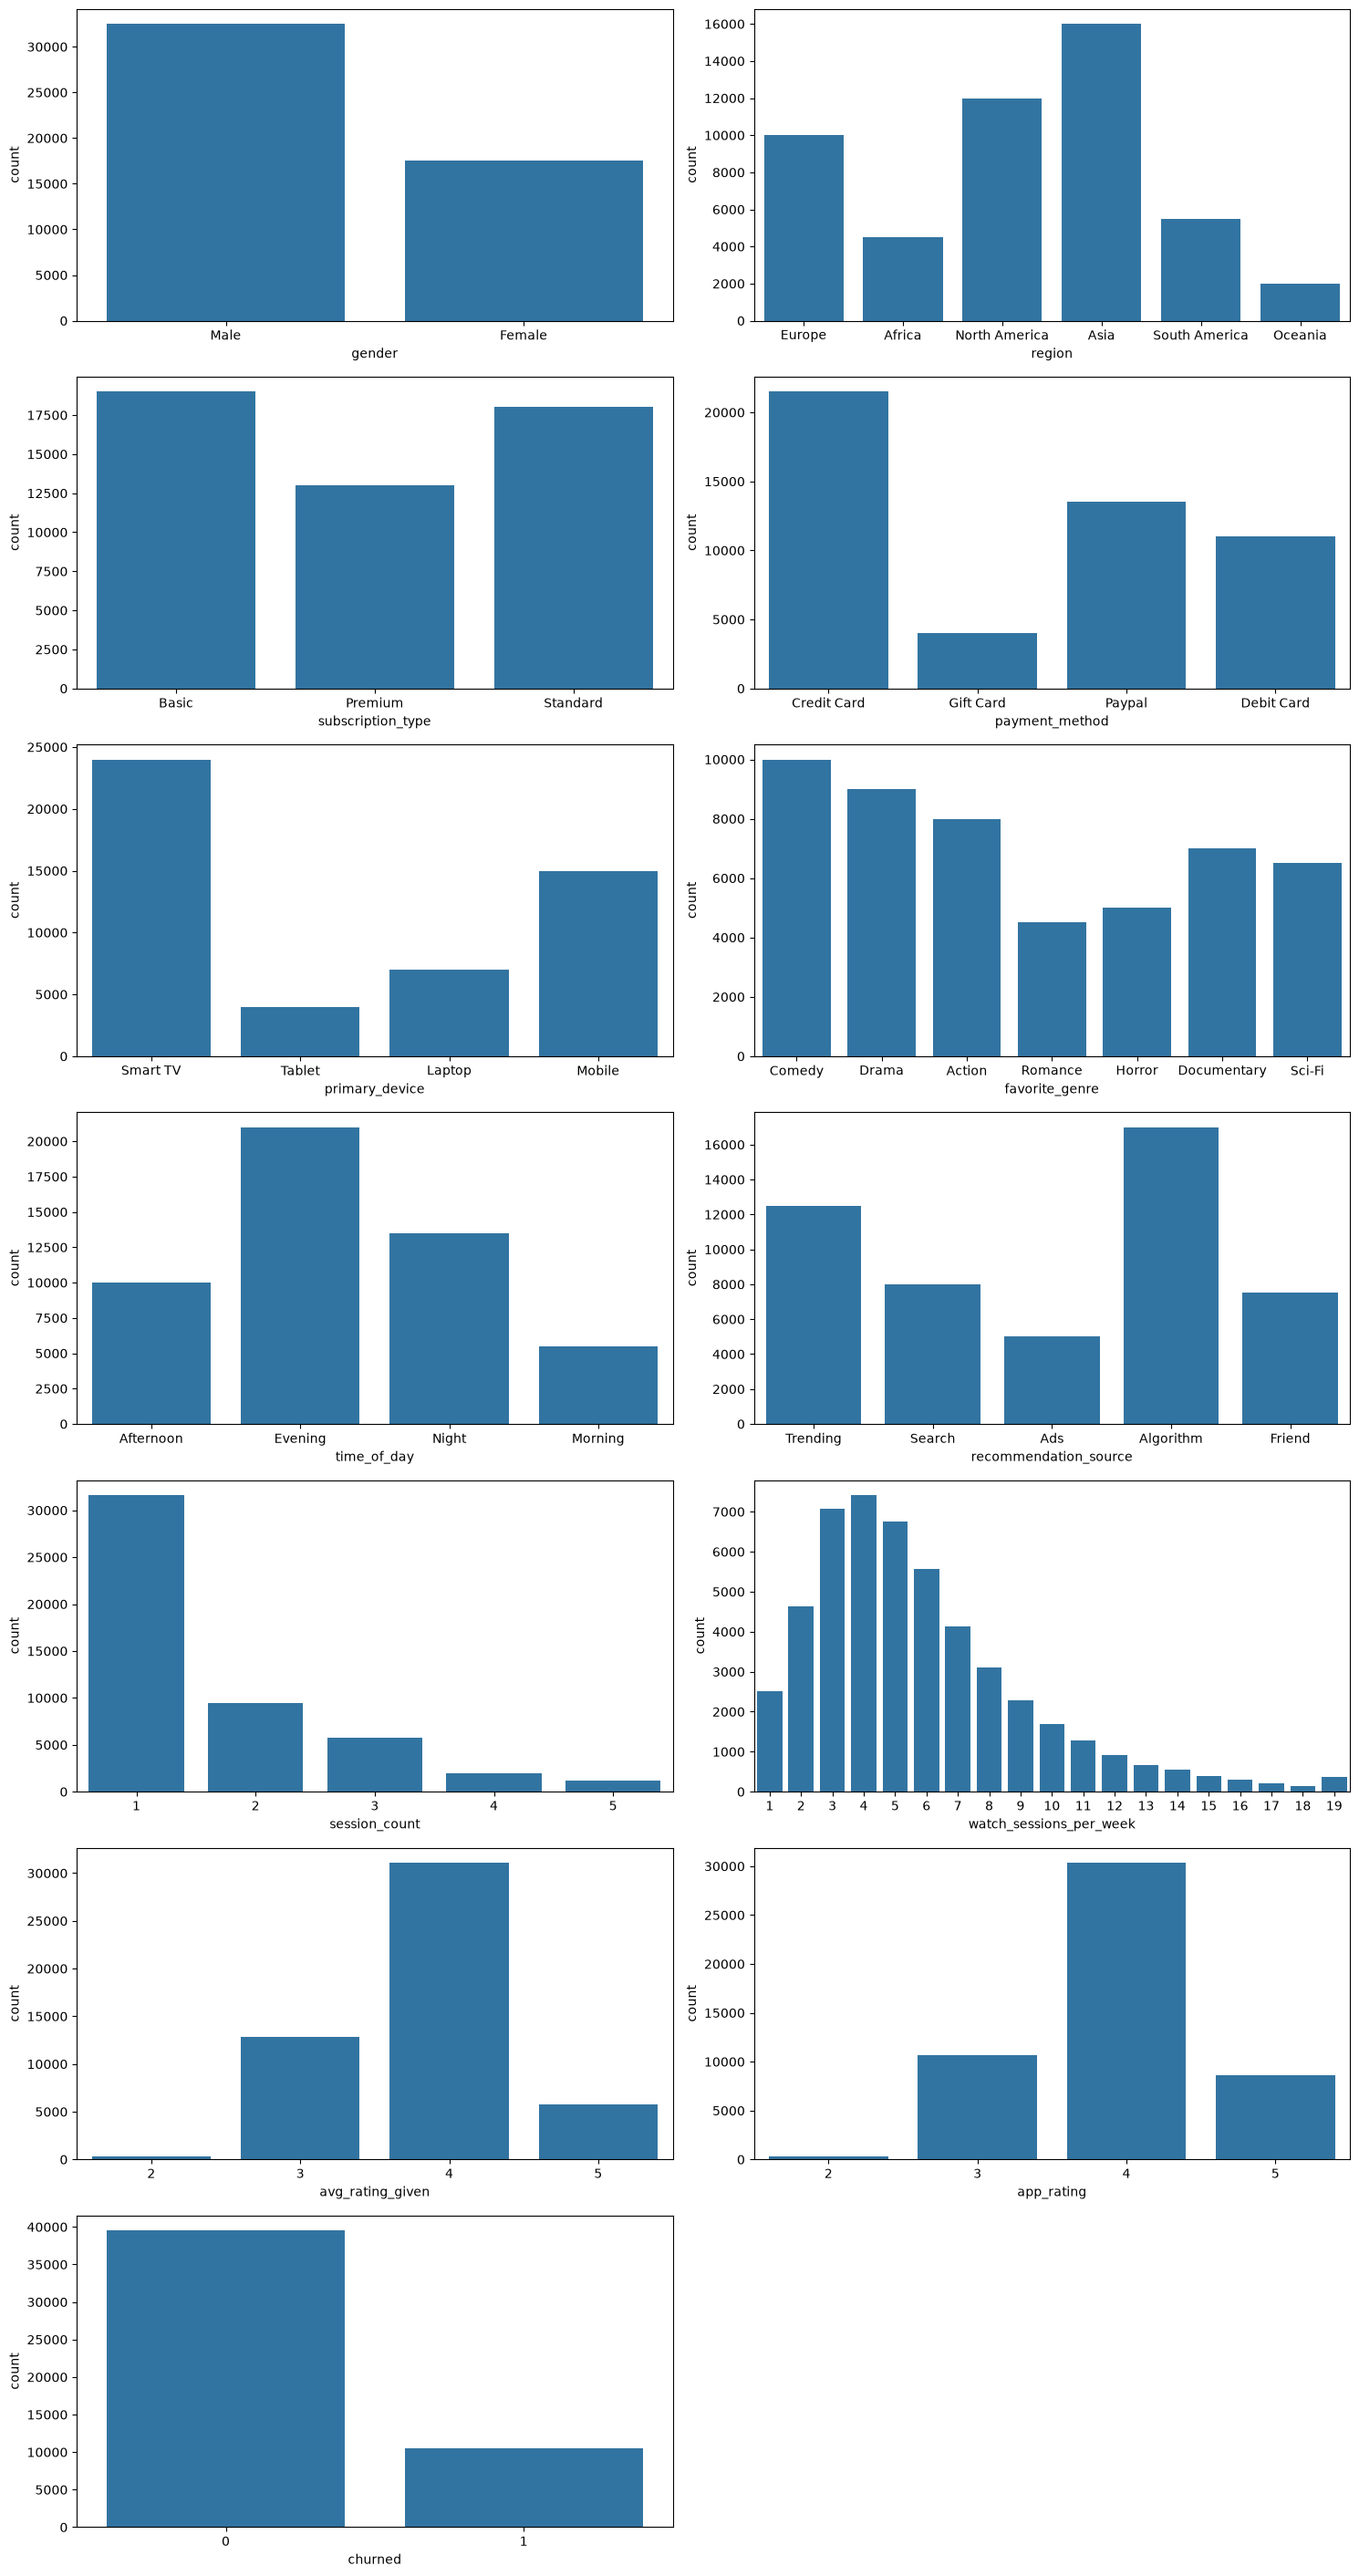

In [19]:
plt.figure(figsize=(15,40))
plot_num = 1
for col in count_col:
    plt.subplot(10,2,plot_num)
    sns.countplot(data=df, x=col)
    plot_num += 1
    plt.tight_layout()

In [20]:
df[numerical_features].describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,39.21590,13.071976,19.0,31.0,37.0,45.0,79.0
account_age_months,50000.0,44.80334,21.890139,1.0,29.0,45.0,60.0,135.0
session_count,50000.0,1.63012,0.988579,1.0,1.0,1.0,2.0,5.0
avg_watch_time_minutes_per_week,50000.0,277.95064,157.604512,15.0,165.0,240.0,349.0,820.0
watch_sessions_per_week,50000.0,5.73146,3.467176,1.0,3.0,5.0,7.0,19.0
completion_rate,50000.0,73.12726,11.148734,23.0,66.0,74.0,81.0,100.0
avg_rating_given,50000.0,3.84456,0.611887,2.0,3.0,4.0,4.0,5.0
app_rating,50000.0,3.94622,0.639168,2.0,4.0,4.0,4.0,5.0
recommendation_click_rate,50000.0,38.64068,19.474178,0.0,24.0,37.0,52.0,100.0
days_since_last_login,50000.0,12.30138,15.453764,0.0,1.0,4.0,22.0,60.0



Histograms of numerical columns

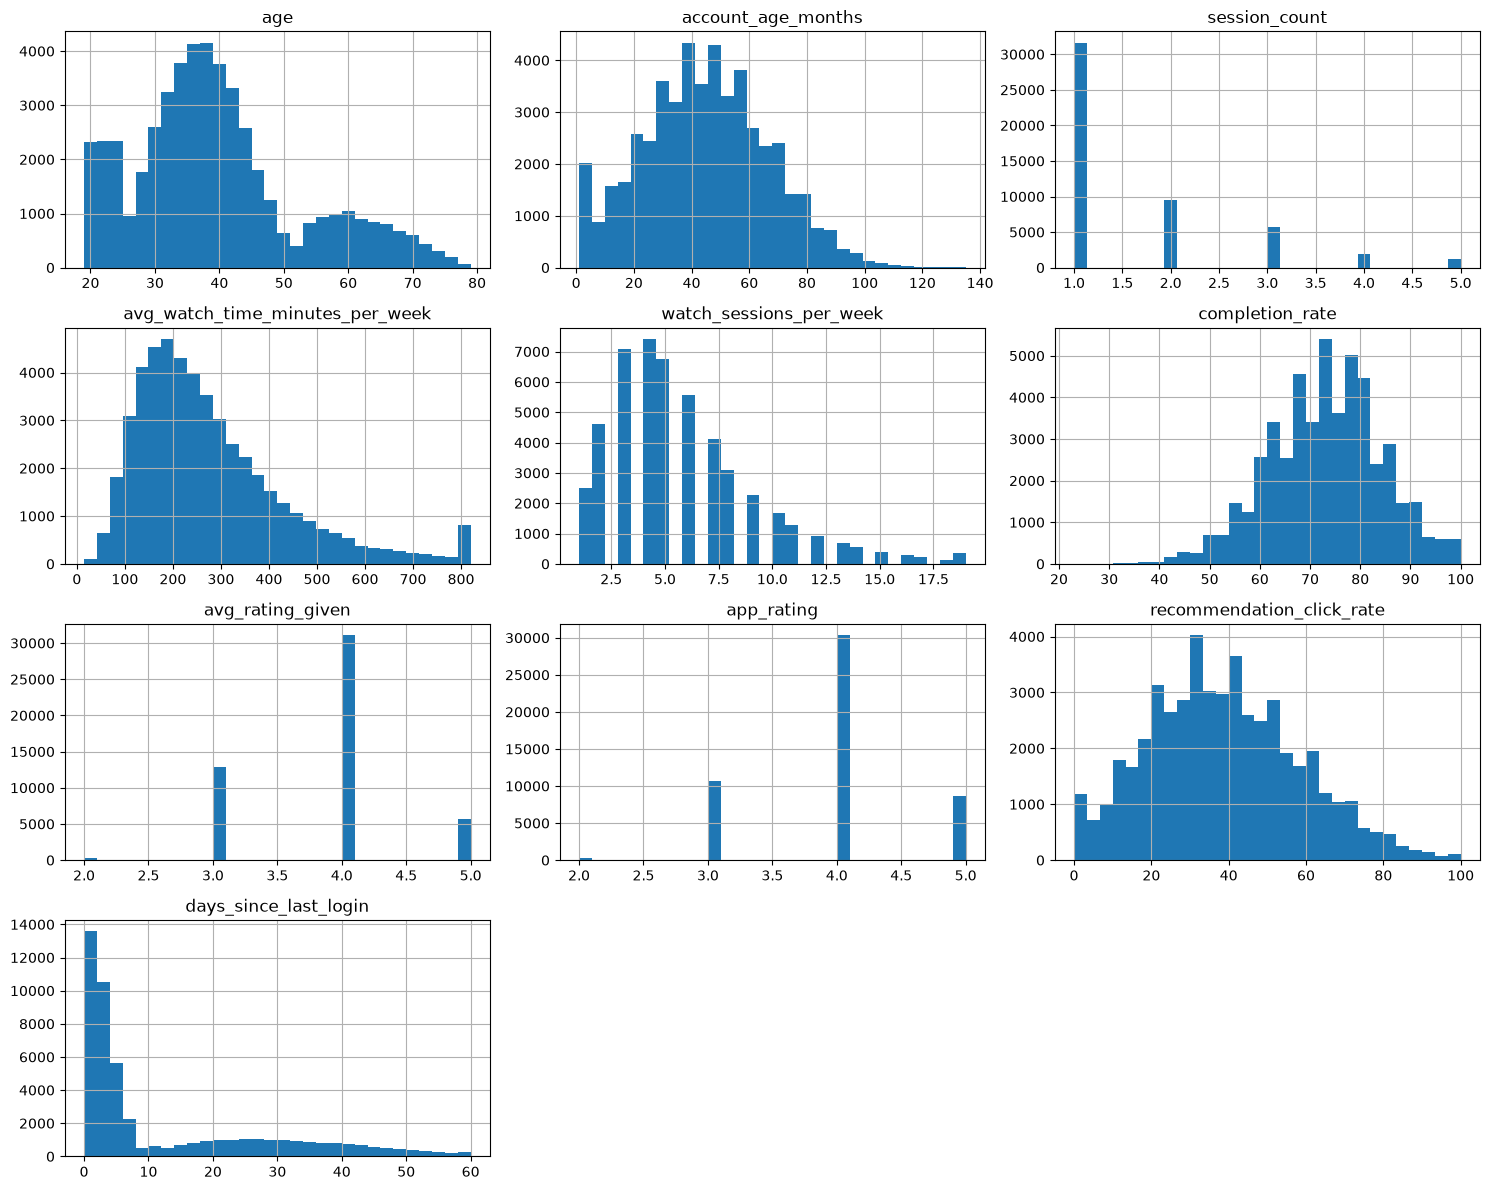

In [21]:
df[numerical_features].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

Plot the Churn distribution for each categorical variable

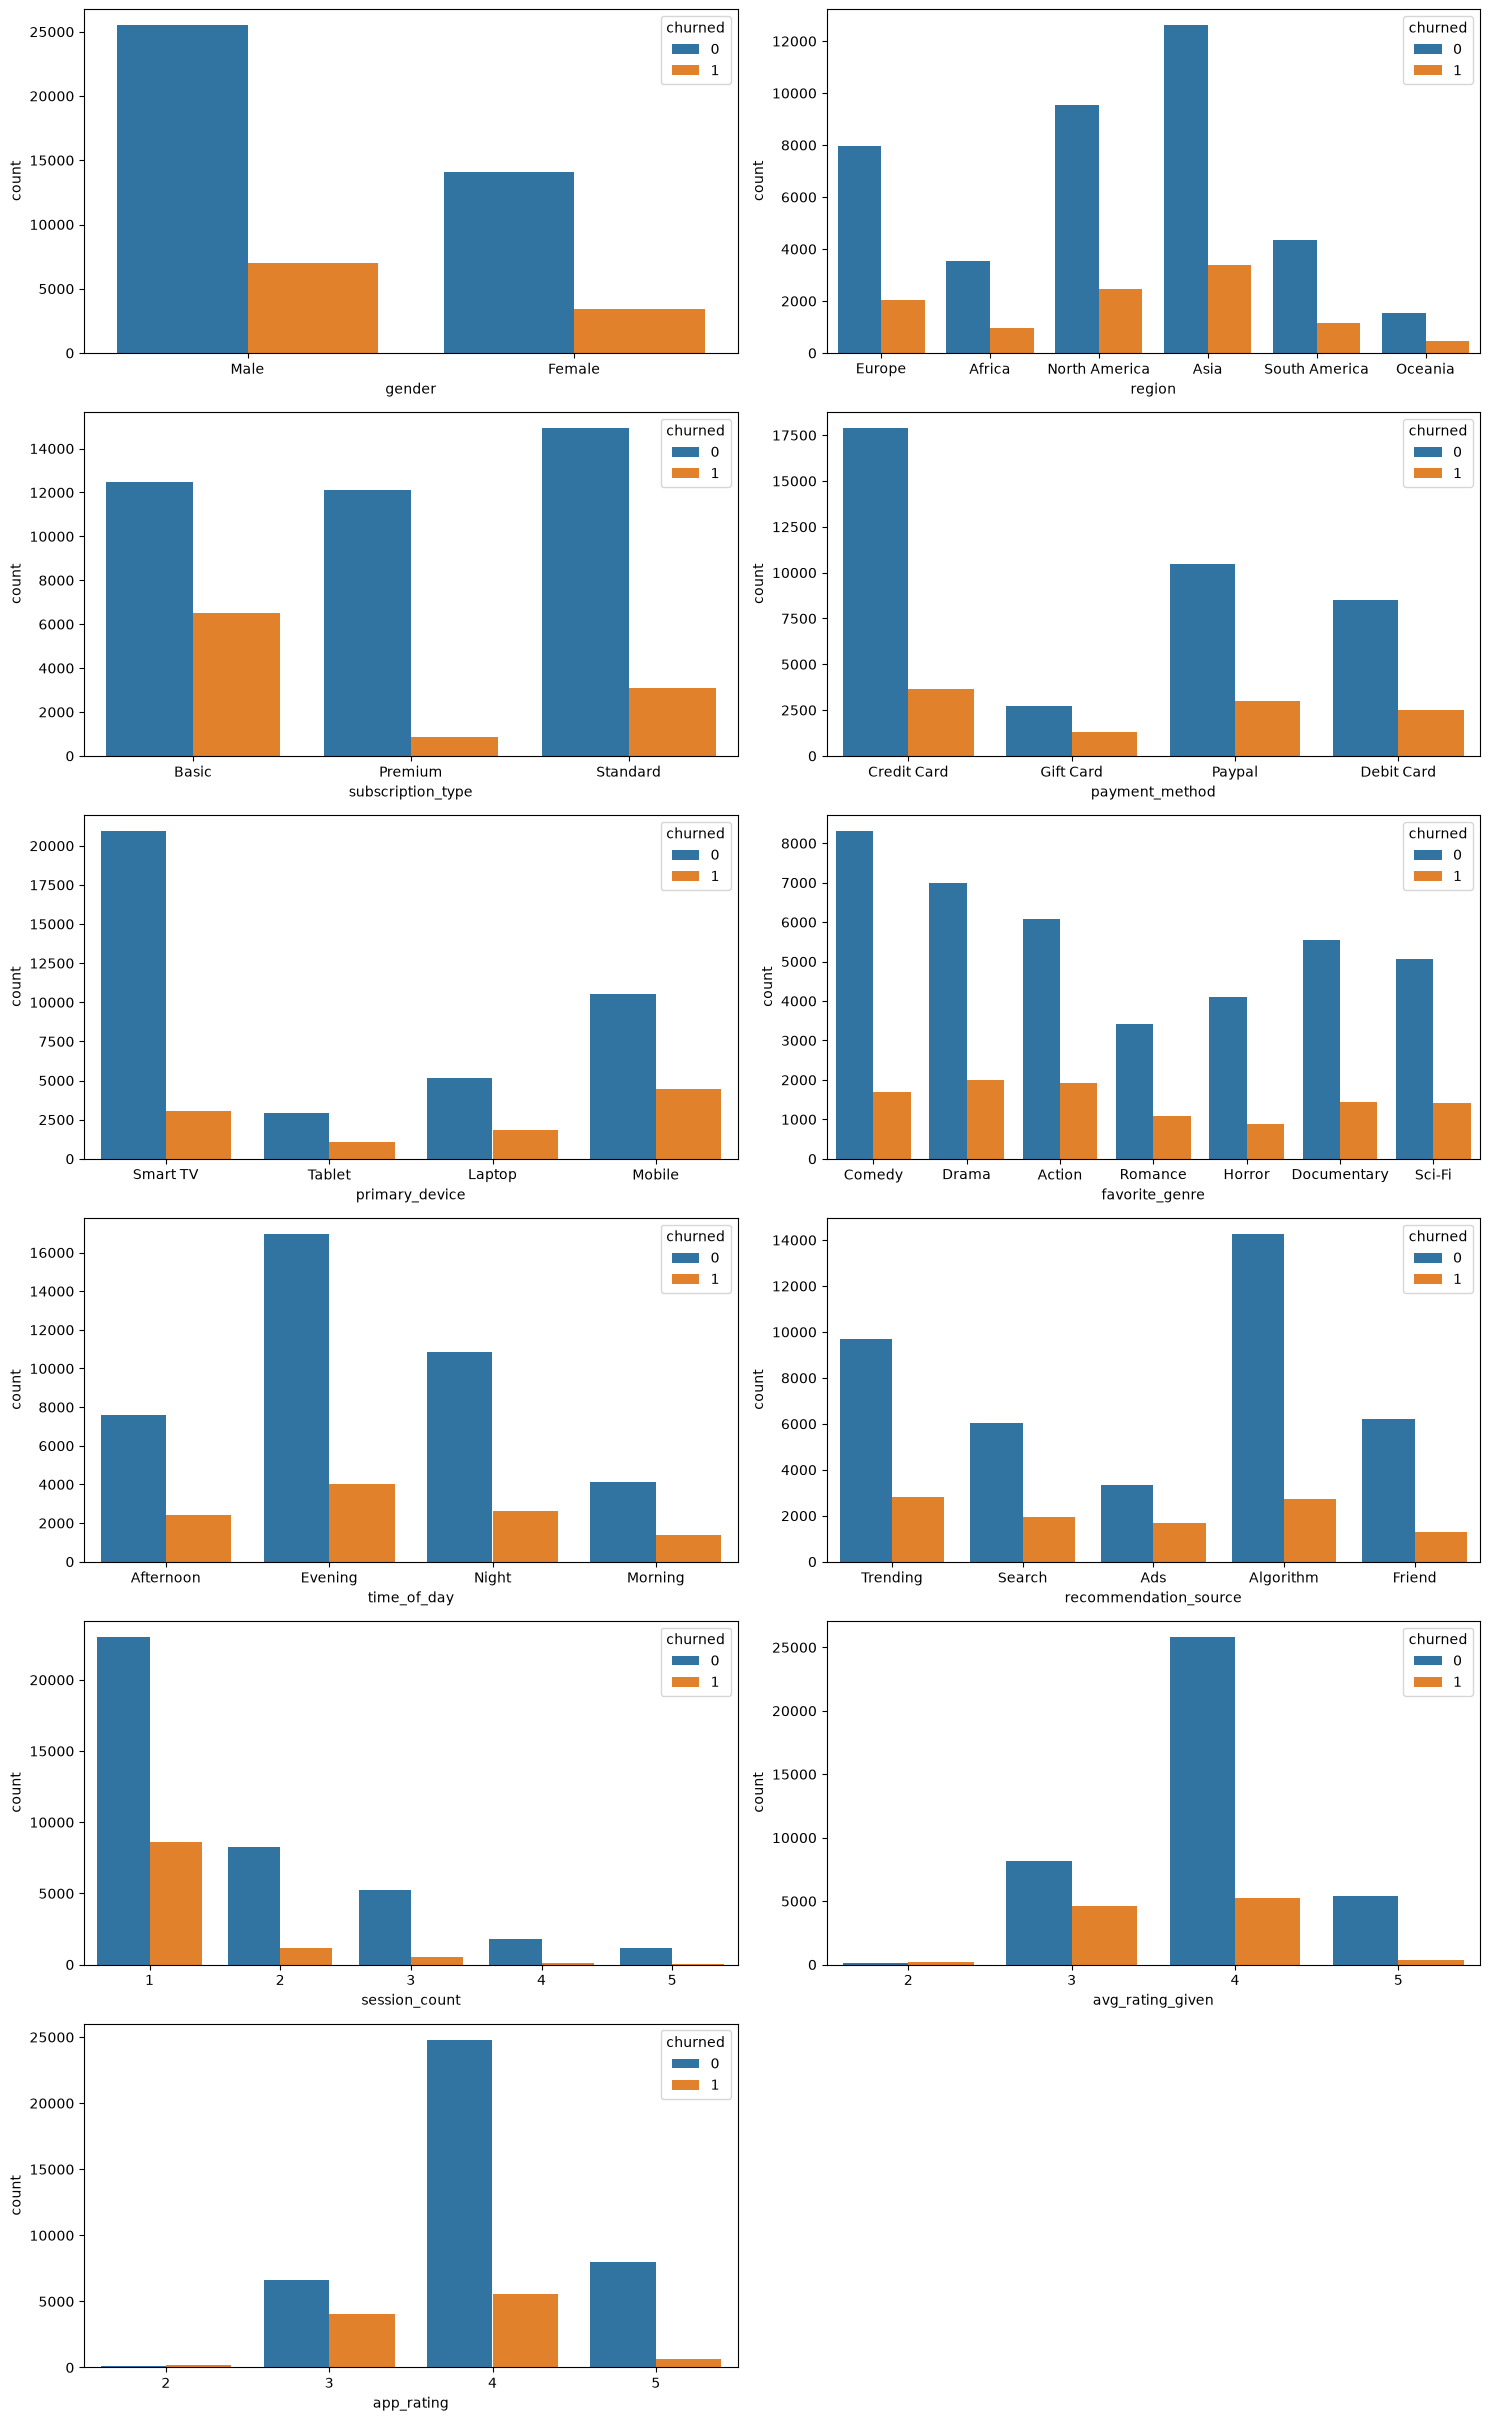

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,40))
plot_num = 1
for col in count_col:
    if df[col].nunique() <= 8 and col != "churned":
        plt.subplot(10,2,plot_num)
        sns.countplot(data=df, x=col, hue="churned")
        plot_num += 1
        plt.tight_layout()

In [23]:
df[numerical_features].skew()


age                                0.740509
account_age_months                 0.129291
session_count                      1.616304
avg_watch_time_minutes_per_week    1.303755
watch_sessions_per_week            1.254629
completion_rate                   -0.174380
avg_rating_given                  -0.079688
app_rating                        -0.095871
recommendation_click_rate          0.322215
days_since_last_login              1.241871
dtype: float64

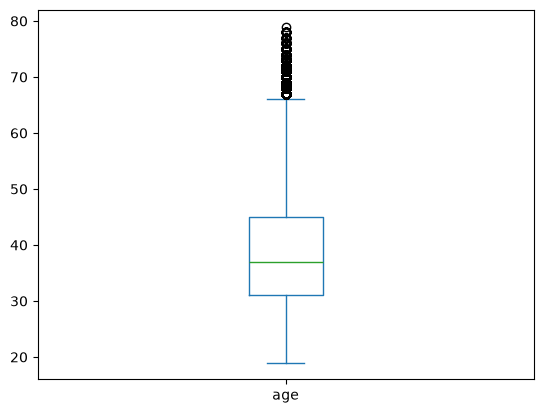

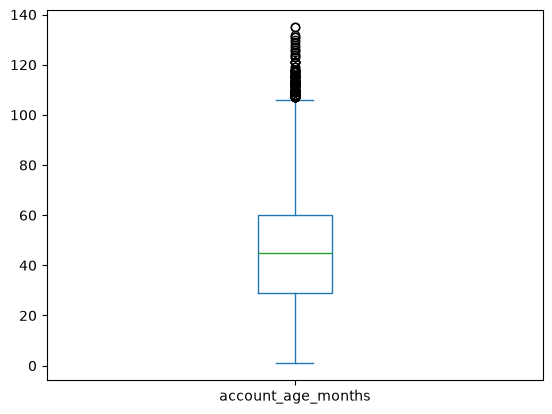

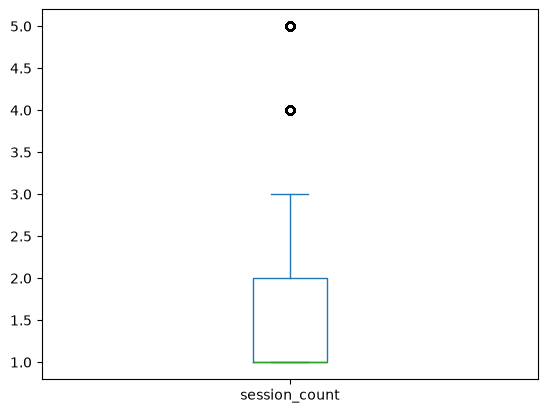

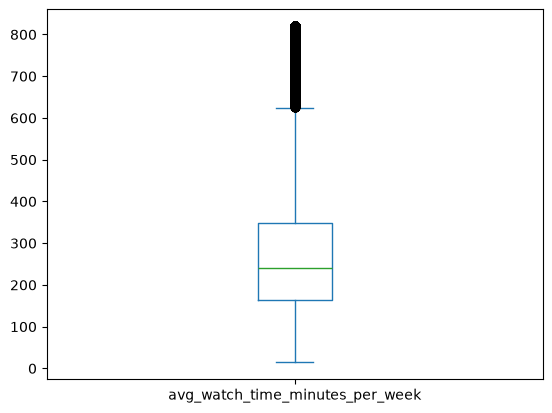

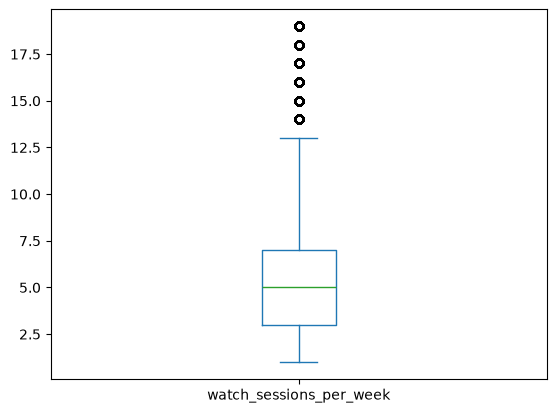

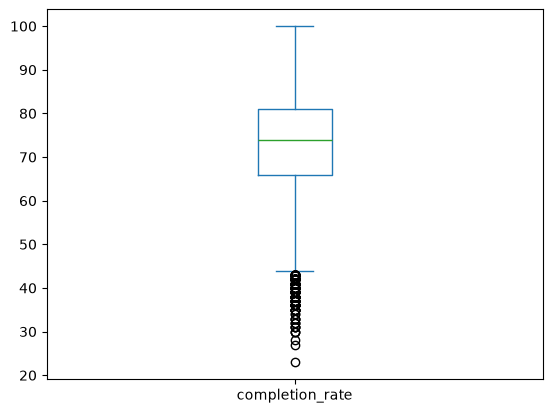

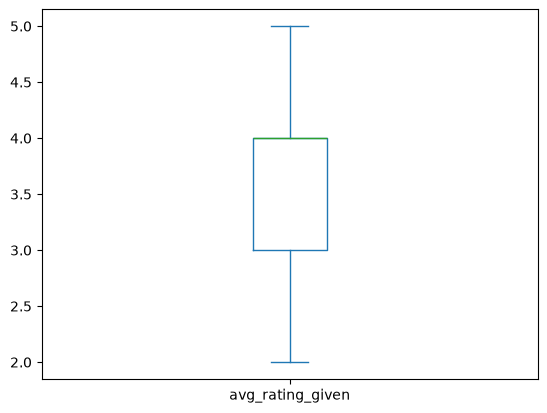

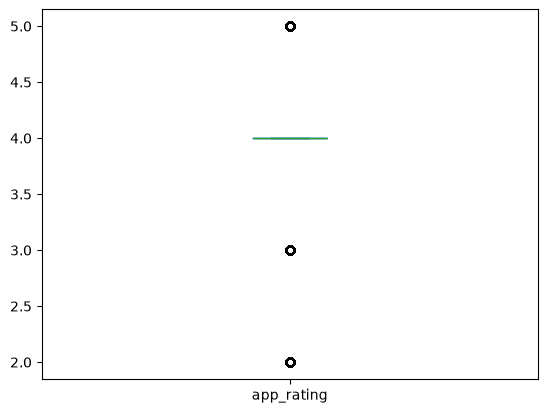

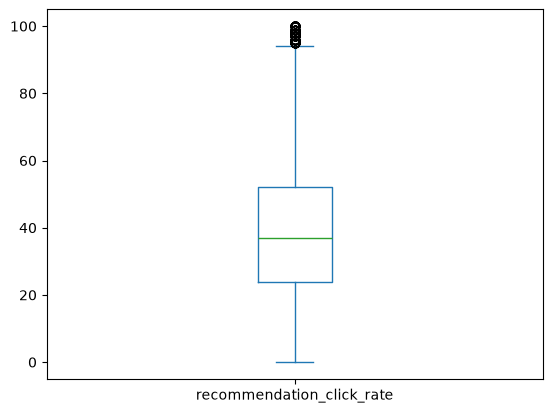

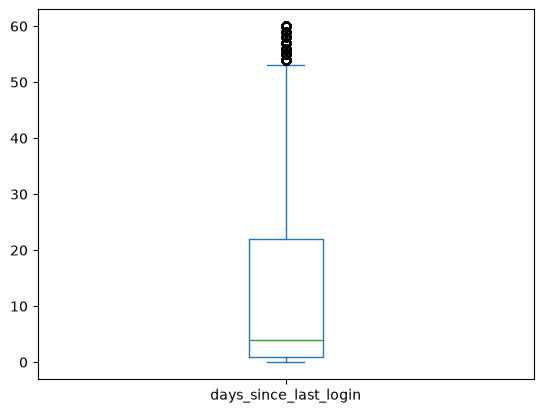

In [25]:
for i in numerical_features:
    df[i].plot(kind='box')
    plt.show()


## Outliers Count

In [26]:
import pandas as pd

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count where values fall outside the boundaries
outliers_count = ((df[numerical_features] < lower_bound) | (df[numerical_features] > upper_bound)).sum()

# Convert to a readable DataFrame
outliers_summary = pd.DataFrame(outliers_count, columns=['Outlier_Count'])
print(outliers_summary)


                                 Outlier_Count
age                                       2277
account_age_months                         132
session_count                             3099
avg_watch_time_minutes_per_week           2210
watch_sessions_per_week                   1968
completion_rate                            286
avg_rating_given                             0
app_rating                               19638
recommendation_click_rate                  168
days_since_last_login                      723


In [27]:
df[numerical_features].min()

age                                19
account_age_months                  1
session_count                       1
avg_watch_time_minutes_per_week    15
watch_sessions_per_week             1
completion_rate                    23
avg_rating_given                    2
app_rating                          2
recommendation_click_rate           0
days_since_last_login               0
dtype: int64

In [28]:
df[numerical_features].max()

age                                 79
account_age_months                 135
session_count                        5
avg_watch_time_minutes_per_week    820
watch_sessions_per_week             19
completion_rate                    100
avg_rating_given                     5
app_rating                           5
recommendation_click_rate          100
days_since_last_login               60
dtype: int64

In [29]:
print("Age below 18:", (df['age'] < 18).sum())

print("Negative account age:",
      (df['account_age_months'] < 0).sum())

print("Negative watch time:",
      (df['avg_watch_time_minutes_per_week'] < 0).sum())

print("Invalid completion rate:",
      ((df['completion_rate'] < 0) |
       (df['completion_rate'] > 100)).sum())

print("Invalid recommendation click rate:",
      ((df['recommendation_click_rate'] < 0) |
       (df['recommendation_click_rate'] > 100)).sum())

print("Negative days since login:",
      (df['days_since_last_login'] < 0).sum())

Age below 18: 0
Negative account age: 0
Negative watch time: 0
Invalid completion rate: 0
Invalid recommendation click rate: 0
Negative days since login: 0


## Correlation Analysis

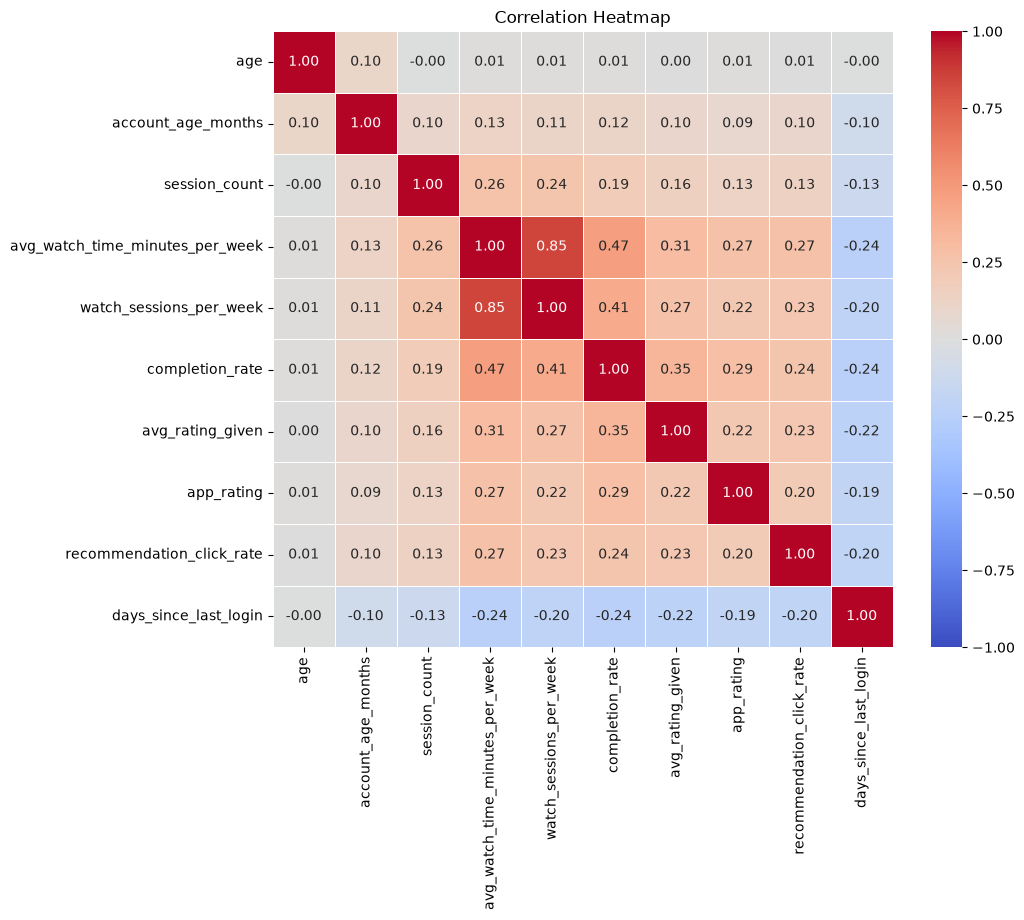

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute the correlation matrix for numerical features
corr_matrix = df[numerical_features].corr()

# 2. Set up the matplotlib figure size
plt.figure(figsize=(10, 8))

# 3. Plot the heatmap
sns.heatmap(
    data=corr_matrix,
    annot=True,  # Shows the correlation numbers inside the squares
    cmap="coolwarm",  # Color palette (blue for negative, red for positive)
    fmt=".2f",  # Rounds the numbers to 2 decimal places
    linewidths=0.5,  # Adds thin white lines between squares
    vmin=-1,  # Set the anchor minimum value for the colorbar
    vmax=1,  # Set the anchor maximum value for the colorbar
)

plt.title("Correlation Heatmap")
plt.show()


In [31]:
target_corr = df[numerical_features].corrwith(df['churned'])
target_corr

age                               -0.076246
account_age_months                -0.153542
session_count                     -0.197122
avg_watch_time_minutes_per_week   -0.313885
watch_sessions_per_week           -0.258165
completion_rate                   -0.301837
avg_rating_given                  -0.247437
app_rating                        -0.250704
recommendation_click_rate         -0.269334
days_since_last_login              0.495006
dtype: float64

## Target Feature Analysis

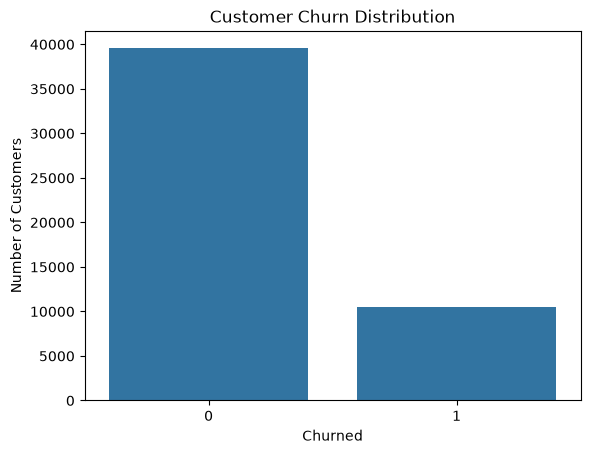

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='churned')

plt.title('Customer Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Number of Customers')
plt.show()

In [33]:
df['churned'].value_counts()

churned
0    39536
1    10464
Name: count, dtype: int64

In [34]:
df['churned'].value_counts(normalize=True) * 100

churned
0    79.072
1    20.928
Name: proportion, dtype: float64

In [35]:
df.groupby('churned')[numerical_features].mean().T

churned,0,1
age,39.728652,37.278574
account_age_months,46.532451,38.270260
session_count,1.730372,1.251338
avg_watch_time_minutes_per_week,303.400648,181.793196
watch_sessions_per_week,6.191952,3.991590
completion_rate,74.858458,66.586296
avg_rating_given,3.922450,3.550268
app_rating,4.028657,3.634748
recommendation_click_rate,41.339033,28.445528
days_since_last_login,8.365945,27.170585
